In [1]:
import cmocean
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import warnings
from pathlib import Path

import pycompo.core.composite as pccompo
import pycompo.core.utils as pcutil
import pycompo.core.plot as pcplot
import pycompo.core.sigtest as pcsig

import hfplot.figure.figure as hffig
from hfplot.settings import STYLES

warnings.filterwarnings(action='ignore')

# Define functions
def calc_pa_driven_conv(ps_laplacian, bg_rho, ellipse_axes):
    equiv_R = np.sqrt(
        ellipse_axes['axis_major_length_idx'] * \
        ellipse_axes['axis_minor_length_idx']
        ) / 2.
    division = ps_laplacian / (equiv_R * bg_rho)
    return np.sign(division) * np.sqrt(abs(division))

# read in configuration file
ana_idf = "ngc5004_opv4_w1"
config_path = '/home/m/m300738/libs/pycompo/config'
config_file = f'{config_path}/settings_{ana_idf}.yaml'
config = pcutil.read_yaml_config(config_file)
ana_times = pcutil.create_analysis_times(config)

### Read in composites

In [2]:
# read in composite and adjust units
inpath = Path(f"{config['data']['outpath']}/{ana_idf}/")
infile_compo = Path(f"{ana_idf}_composite_rainbelt.nc")
rb_compo = xr.open_dataset(str(inpath/infile_compo))

# read in p-values and calculate field significance
infile_pvalue = Path(f"{ana_idf}_pvalue_rainbelt.nc")
rb_pvalue = xr.open_dataset(str(inpath/infile_pvalue))
rb_sigmask = pcsig.get_field_significance(rb_pvalue, alpha_FDR=0.1)

# correct composites by population means
rb_popmeans = []
ipath_popms = Path(f"{config['data']['outpath']}/{ana_idf}/popmeans/")

for start_time, end_time in zip(ana_times, ana_times[1:]):
    fdate_str = pcutil.create_ftime_str(start_time, end_time)
    ifile = Path(f"{ana_idf}_popmeans_rainbelt_{fdate_str}.nc")
    rb_popmeans.append(
        xr.open_dataset(ipath_popms/ifile).mean(dim='time').compute()
        )
rb_popmeans = xr.concat(rb_popmeans, dim='time').mean(dim="time")

rb_compo_corrected = rb_compo - rb_popmeans

# calculate pressure-anomaly-driven convergence
rb_compo_corrected['pa_driven_conv'] = calc_pa_driven_conv(
    rb_compo_corrected['ps_ano_laplacian'],
    rb_compo['bg_sfc_rho'],
    rb_compo[['axis_major_length_idx', 'axis_minor_length_idx']],
) * 10**5

rb_compo_corrected = pccompo.adjust_units(
    rb_compo_corrected, rb_compo_corrected.data_vars,
    )

### Define plotting function

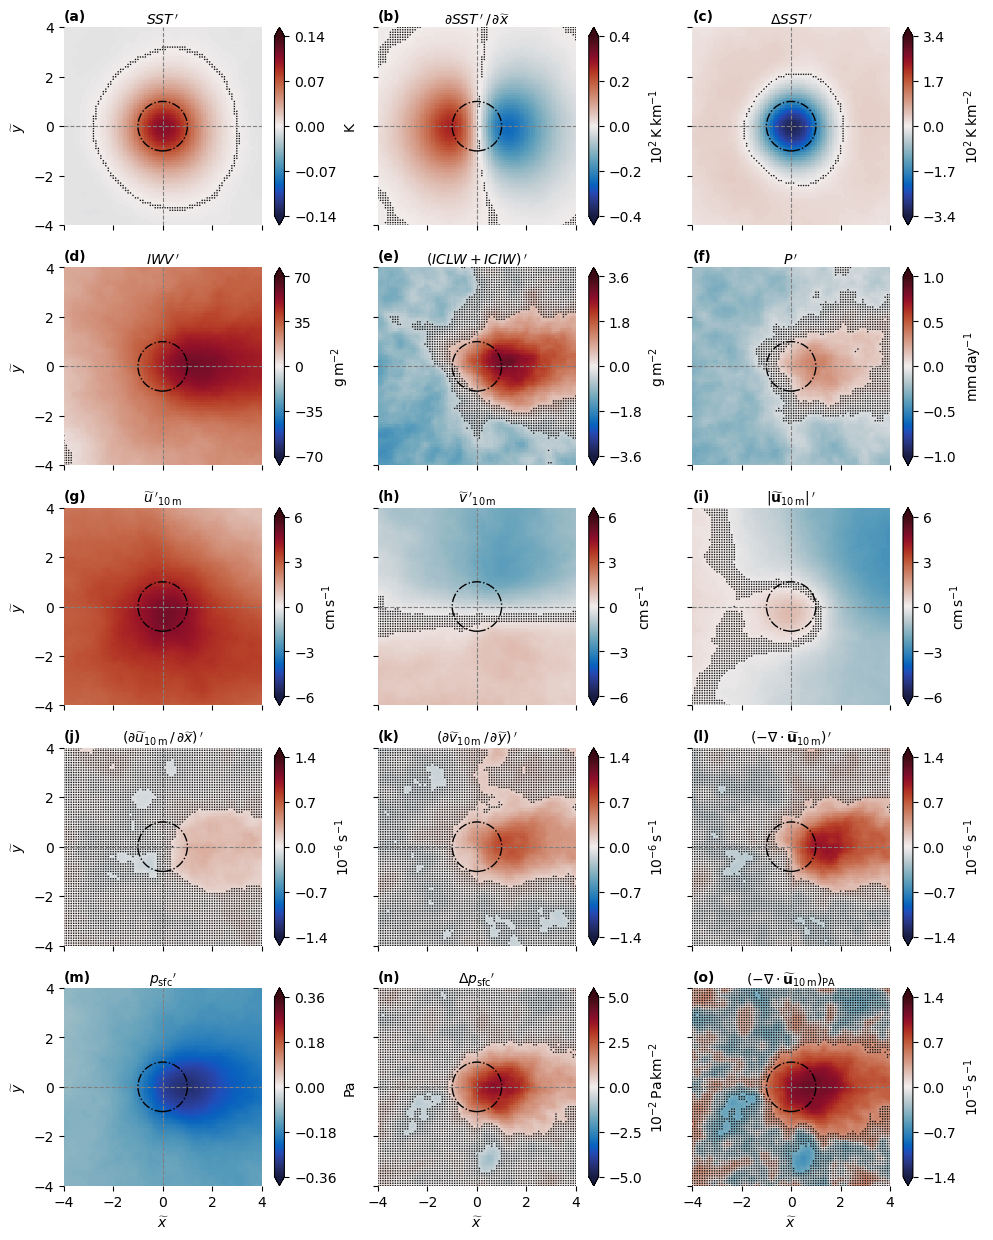

In [ ]:
plotdata = rb_compo_corrected
sigmask = rb_sigmask

CRANGE = {
    'ts_ano': [-0.14, 0.14],
    'downwind_ts_ano_grad': [-0.4, 0.4],
    'ts_ano_laplacian': [-3.4, 3.4],
    'prw_ano': [-70, 70],
    'clwvi_ano': [-3.6, 3.6],
    'pr_ano': [-1., 1.],
    'uas_ano': [-6, 6],
    'vas_ano': [-6, 6],
    'sfcwind_ano': [-6, 6],
    'uas_conv_ano': [-1.4, 1.4],
    'vas_conv_ano': [-1.4, 1.4],
    'sfcwind_conv_ano': [-1.4, 1.4],
    'ps_ano': [-0.36, 0.36],
    'ps_ano_laplacian': [-5, 5],
    'pa_driven_conv': [-1.4, 1.4],
}
CLABEL = {
    'ts_ano': "K",
    'downwind_ts_ano_grad': "$10^{2}\,\mathrm{K}\,\mathrm{km}^{-1}$",
    'ts_ano_laplacian': "$10^{2}\,\mathrm{K}\,\mathrm{km}^{-2}$",

    'uas_ano': "$\mathrm{cm\,s^{-1}}$",
    'vas_ano': "$\mathrm{cm\,s^{-1}}$",
    'sfcwind_ano': "$\mathrm{cm\,s^{-1}}$",

    'uas_conv_ano': "$10^{-6}\,\mathrm{s^{-1}}$",
    'vas_conv_ano': "$10^{-6}\,\mathrm{s^{-1}}$",
    'sfcwind_conv_ano': "$10^{-6}\,\mathrm{s^{-1}}$",
    
    'ps_ano': "Pa",
    'ps_ano_laplacian': "$10^{-2}\,\mathrm{Pa}\,\mathrm{km}^{-2}$",
    'pa_driven_conv': "$10^{-5}\,\mathrm{s^{-1}}$",

    'prw_ano': "$\mathrm{g\,m^{-2}}$",
    'clwvi_ano': "$\mathrm{g\,m^{-2}}$",
    'pr_ano': "$\mathrm{mm\,day^{-1}}$",
}
TITLE = {
    'ts_ano': "$SST\,\mathrm{'}$",
    'downwind_ts_ano_grad': "$\partial SST\,\mathrm{'}\,/\,\partial\\widetilde{x}$",
    'ts_ano_laplacian': "$\Delta SST\,\mathrm{'}$",

    'uas_ano': "$\\widetilde{u}\,\mathrm{'}_{\mathrm{10\,m}}$",
    'vas_ano': "$\\widetilde{v}\,\mathrm{'}_{\mathrm{10\,m}}$",
    'sfcwind_ano': "$|\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}|\,\mathrm{'}$",

    'uas_conv_ano': "$\left(\partial \\widetilde{u}_{\mathrm{10\,m}}\,/\,\partial\\widetilde{x}\\right)\,\mathrm{'}$",
    'vas_conv_ano': "$\left(\partial \\widetilde{v}_{\mathrm{10\,m}}\,/\,\partial\\widetilde{y}\\right)\,\mathrm{'}$",
    'sfcwind_conv_ano': "$\left(-\\nabla\cdot\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}\\right)\,\mathrm{'}$",
    
    'ps_ano': "$p_{\mathrm{sfc}}\mathrm{'}$",
    'ps_ano_laplacian': "$\Delta p_{\mathrm{sfc}}\mathrm{'}$",
    'pa_driven_conv': "$\left(-\\nabla\cdot\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}\\right)_{\mathrm{PA}}$",

    'prw_ano': "$IWV\,\mathrm{'}$",
    'clwvi_ano': "$\left(ICLW + ICIW\\right)\,\mathrm{'}$",
    'pr_ano': "$P\,\mathrm{'}$",
}

# Plotting
fig, axes = hffig.init_subfig(
    style=None, asprat=(10, 12.5), nrow=5, ncol=3, sharex=True, sharey=True,
    )

for i, var in enumerate(CRANGE.keys()):
    pl = axes.ravel()[i].pcolormesh(
        plotdata[var]['En_rota2_featcen_x'],
        plotdata[var]['En_rota2_featcen_y'],
        plotdata[var].transpose(),
        vmin=CRANGE[var][0], vmax=CRANGE[var][1], cmap=cmocean.cm.balance, 
    )
    if var != 'pa_driven_conv':
        pcplot.plot_sigmask(axes.ravel()[i], sigmask[var])
    else:
        pcplot.plot_sigmask(axes.ravel()[i], sigmask['ps_ano_laplacian'])
    pcplot.plot_feature_grid(
        axes.ravel()[i],
        plotdata['En_rota2_featcen_x'], plotdata['En_rota2_featcen_y'],
        )
    pcplot.plot_feature_circle(axes.ravel()[i], (0, 0), 1, lw=1)
    plt.colorbar(
        pl, ax=axes.ravel()[i], orientation='vertical', label=CLABEL[var],
        extend='both', ticks=np.linspace(CRANGE[var][0], CRANGE[var][1], 5)
        )
    axes.ravel()[i].set_aspect('equal')
    for spine in axes.ravel()[i].spines.values():
        spine.set_visible(False)
    axes.ravel()[i].set_title(TITLE[var], fontsize=10, pad=1.8)

hffig.set_limit(axes, [-4, 4], [-4, 4])
hffig.set_ticks(axes, [-4, -2, 0, 2, 4], [-4, -2, 0, 2, 4])
hffig.set_label(axes, '$\\widetilde{x}$', '$\\widetilde{y}$')

# Save plot
plt.tight_layout()
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure04.png')
plt.savefig(str(outpath/outfile), dpi=600, bbox_inches='tight')
plt.show()